<a href="https://colab.research.google.com/github/gelisam/colab/blob/main/linear_decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The sine wave fits inside the range $[-1.0,1.0]$, but many piecewise-linear approximations don't. We want to find the best piecewise-linear approximation which does respect this constraint.

Why? Maybe this will encode the movement for an enemy oscillating in a tight corridor, and we don't want it to hit the walls. Or maybe this is the output of a DC to AC current converter, and we don't want to damage the downstream device. The real reason is that this is a simple setup for demonstrating a neat technique for the formal verification of a ReLU-based neural network: _piecewise-linear decomposition_.

Anyway, let's start simple, with a visualisation demonstrating how an otherwise-reasonable piecewise-linear approximation might spill outside the $[-1.0,1.0]$ range:

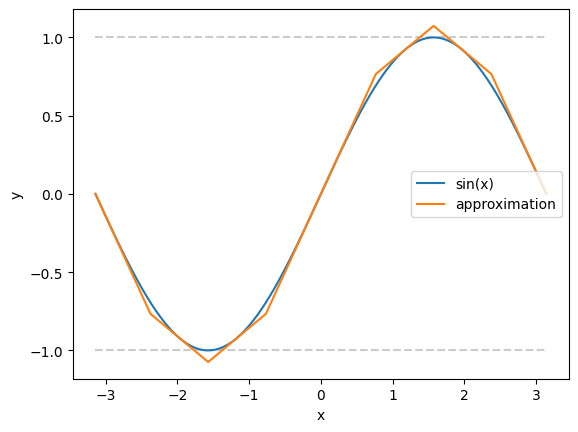

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def where(q, a, b):
    "Use this function to replace an if-statement."
    return (q * a) + (~q) * b

def segment(x, left, right, x0, y0, slope):
  """The line with the given slope which intersects (x0, y0),
  but only between x=left and x=right; zero otherwise."""
  return where(
    x <= left,
    0.0,
    where(
      x <= right,
      slope * (x - x0) + y0,
      0.0
    )
  )

def intersect_x(x0, y0, slope0, x1, y1, slope1):
  """Find the x coordinate where
  segment(_, _, _, x0, y0, slope0) is equal to
  segment(_, _, _, x1, y1, slope1)."""
  # slope0 * (x - x0) + y0 = slope1 * (x - x1) + y1
  # slope0 * x - slope0 * x0 + y0 = slope1 * x - slope1 * x1 + y1
  # slope0 * x - slope1 * x = -slope1 * x1 + y1 + slope0 * x0 - y0
  return (-(slope1 * x1) + y1 + (slope0 * x0) - y0) / (slope0 - slope1)

def segments(x, left0, xy_slopes: list[tuple[float, float, float]], right0):
  """Given a list of (x, y, slope) segments,
  [      ,-'] ['-.      ]
  [   ,-'   ] [   '-.   ]
  [.-'      ] [      '-.]
  find the intersection points between those segments,
  connect those segments where they intersect,
  [         ]
  [   ,-.   ]
  [.-'   '-.]
  but only between x=left0 and x=right0; zero otherwise."""
  left = left0
  out = 0
  for (x0, y0, slope0), (x1, y1, slope1) in zip(xy_slopes[:-1], xy_slopes[1:]):
    right = intersect_x(x0, y0, slope0, x1, y1, slope1)
    out = out + segment(x, left, right, x0, y0, slope0)
    left = right

  (x1, y1, slope1) = xy_slopes[-1]
  right = right0
  out = out + segment(x, left, right, x1, y1, slope1)

  return out

def sin_triple(x0):
  """Complete the triple (x, sin(x), slope of sin(x))."""
  # The derivative of sin(x) is cos(x)
  return (x0, np.sin(x0), np.cos(x0))

def plot_approximation(predicted_y, true_y, x):
    """Plot the predictions and the actual data points"""
    plt.plot(x, x*0+1.0, linestyle='dashed', color='0.8')
    plt.plot(x, x*0-1.0, linestyle='dashed', color='0.8')
    plt.plot(x, true_y, label="sin(x)")
    plt.plot(x, predicted_y, label="approximation")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


# sin(x) and its approximation between -π and π
pi = np.pi
x = torch.linspace(-pi, pi, 1000)
true_y = torch.sin(x)
predicted_y = segments(x, -pi, [
  sin_triple(-8*pi/8),
  sin_triple(-5*pi/8),
  sin_triple(-3*pi/8),
  sin_triple( 0*pi/8),
  sin_triple( 3*pi/8),
  sin_triple( 5*pi/8),
  sin_triple( 8*pi/8)
], pi)
plot_approximation(predicted_y, true_y, x)

The technique I want to demonstrate works with ReLU-based neural networks, so let's now try to train one to approximate the sine wave.

99 0.13421869277954102
199 0.11986301839351654
299 0.10762957483530045
399 0.09673739969730377
499 0.08684960007667542
599 0.07781784236431122
699 0.06959011405706406
799 0.062149882316589355
899 0.055487941950559616
999 0.04958789795637131
1099 0.04441695660352707
1199 0.03992439806461334
1299 0.03604510799050331
1399 0.03270513191819191
1499 0.02982773631811142
1599 0.02733898162841797
1699 0.025171345099806786
1799 0.023266997188329697
1899 0.0215772558003664
1999 0.0200632493942976
2099 0.018694497644901276
2199 0.017447642982006073
2299 0.016305606812238693
2399 0.01525435782968998
2499 0.014285484328866005
2599 0.013393646106123924
2699 0.012568794190883636
2799 0.0118056396022439
2899 0.011099271476268768
2999 0.010445361956954002
3099 0.009840210899710655
3199 0.009279790334403515
3299 0.008760630153119564
3399 0.008279666304588318
3499 0.0078333280980587
3599 0.007419338449835777
3699 0.007034602575004101
3799 0.006676810793578625
3899 0.00634409487247467
3999 0.00603389181196

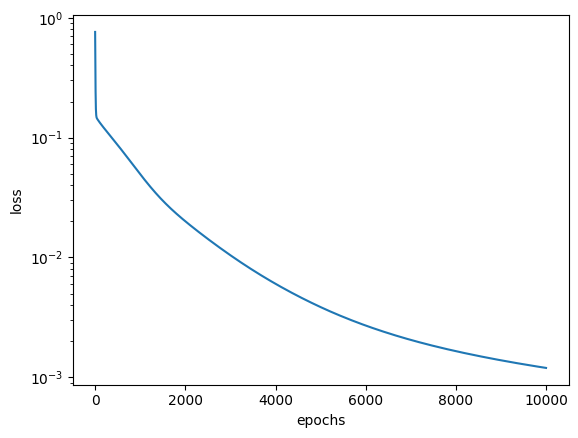

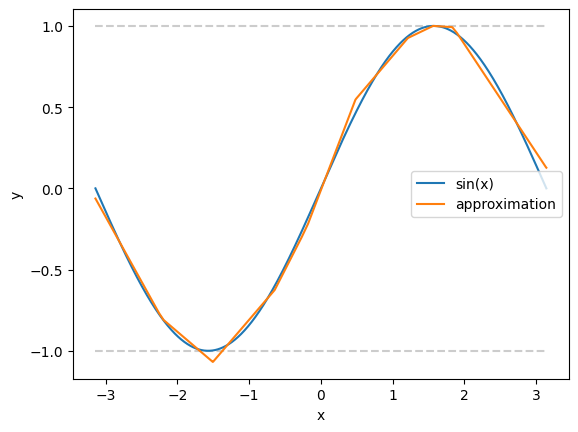

In [18]:
import einops
from einops.layers.torch import EinMix

learning_rate = 1e-2
epochs = 10000
layer_sizes = [16]

x1 = einops.rearrange(x, 'x -> x ()')
true_y1 = einops.rearrange(true_y, 'y -> y ()')

input_size = 1
output_size = 1
layer_input_sizes = [input_size] + layer_sizes
layer_output_sizes = layer_sizes + [output_size]
layers = [
  torch.nn.Sequential(
    torch.nn.Linear(layer_input_size, layer_output_size),
    torch.nn.ReLU()
  ) for layer_input_size, layer_output_size in zip(layer_input_sizes[:-1], layer_output_sizes[:-1])
] + [
  torch.nn.Linear(layer_input_sizes[-1], layer_output_sizes[-1])
]

model = torch.nn.Sequential(*layers)
loss_fn = torch.nn.MSELoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

def plot_loss(losses):
    """Plot the loss curve"""
    plt.plot(range(len(losses)), losses)
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.yscale('log')
    plt.show()

losses = []
for t in range(epochs):
    predicted_y = model(x1)

    loss = loss_fn(predicted_y, true_y1)
    losses.append(loss.item())
    if t % 100 == 99:
        print(t, loss.item())

    optimizer.zero_grad()

    loss.backward()

    with torch.no_grad():
        optimizer.step()

# Always plot the loss curve
plot_loss(losses)

# Check with the plot!
plot_approximation(predicted_y.detach(), true_y, x)